# 02 Data Cleaning — Thailand Economic Analysis System

**วัตถุประสงค์:** แก้ปัญหาทุกอย่างที่พบใน `01_data_overview.ipynb` ก่อนส่งต่อไป analysis

| Step | ปัญหา | วิธีแก้ |
|---|---|---|
| 1 | Time window ไม่ align | Clip ทุก dataset ≥ 2003-01-01 |
| 2 | Market daily gaps | Forward fill ≤ 5 วัน |
| 3 | FRED monthly gaps | Forward fill ≤ 2 เดือน |
| 4 | Macro annual gaps | Linear interpolate |
| 5 | Outliers ใน return | Winsorize 1%/99% |
| 6 | 3 frequency ต่างกัน | Resample → unified monthly |

**Output:** `data/processed/unified_monthly.csv` — พร้อมใช้ใน `03_correlation_analysis.ipynb`

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RAW_DIR  = Path('../../data/raw')
PROC_DIR = Path('../../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

CLIP_START = pd.Timestamp('2003-01-01')
CLIP_END   = pd.Timestamp('2025-12-31')

print(f'Output dir : {PROC_DIR.resolve()}')
print(f'Time window: {CLIP_START.date()} → {CLIP_END.date()}')

Output dir : /home/ppt/notebook/Reddit-Twitter-Sentiment-Market-Trend-Thailand/data/processed
Time window: 2003-01-01 → 2025-12-31


In [2]:
def load_market(name):
    df = pd.read_csv(RAW_DIR / f'{name}_market_signals.csv', parse_dates=['date'])
    return df.set_index('date')['close'].rename(name)

def load_macro(filename, col):
    df = pd.read_csv(RAW_DIR / filename)
    df['year']  = pd.to_numeric(df['year'],  errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna(subset=['year','value']).set_index('year')['value'].rename(col)

def load_fred(name):
    df = pd.read_csv(RAW_DIR / f'fred_{name}.csv', parse_dates=['date'])
    return df.set_index('date')['value'].rename(name)

MARKET_NAMES = ['SET_index','USD_THB','vix','gold','oil','sp500','us_10yr_treasury','nasdaq']
market_raw = pd.concat([load_market(n) for n in MARKET_NAMES], axis=1).sort_index()

macro_raw = pd.concat([
    load_macro('consumption_pct_gdp_TH.csv',     'consumption'),
    load_macro('lending_rate_TH.csv',             'lending_rate'),
    load_macro('inflation_TH.csv',                'inflation'),
    load_macro('thailand_unemployment_rate.csv',  'unemployment'),
    load_macro('gross_capital_formation_TH.csv',  'business_invest'),
    load_macro('exports_pct_gdp_TH.csv',          'exports_pct_gdp'),
    load_macro('imports_pct_gdp_TH.csv',          'imports_pct_gdp'),
    load_macro('imf_gdp_growth_TH.csv',           'gdp_growth'),
    load_macro('govt_expenditure_pct_gdp_TH.csv', 'govt_expenditure'),
    load_macro('govt_debt_pct_gdp_TH.csv',        'govt_debt'),
], axis=1).sort_index()

FRED_NAMES = ['th_exchange_rate_real','th_us_imports','th_property_prices','th_uncertainty',
              'us_fed_funds_rate','us_cpi_monthly','us_unemployment','us_industrial_prod',
              'global_uncertainty','us_consumer_sentiment','us_govt_spending']
fred_raw = pd.concat([load_fred(n) for n in FRED_NAMES], axis=1).sort_index()

print('Raw shapes (before cleaning):')
print(f'  market : {market_raw.shape}  {market_raw.index[0].date()} → {market_raw.index[-1].date()}')
print(f'  macro  : {macro_raw.shape}   year {int(macro_raw.index.min())} → {int(macro_raw.index.max())}')
print(f'  fred   : {fred_raw.shape}  {fred_raw.index[0].date()} → {fred_raw.index[-1].date()}')

Raw shapes (before cleaning):
  market : (6088, 8)  2003-01-02 → 2026-05-08
  macro  : (31, 10)   year 2001 → 2031
  fred   : (280, 11)  2003-01-01 → 2026-04-01


## Step 1: Align Time Window (2003-01-01 → 2025-12-31)

ตัดข้อมูลก่อนปี 2003 ออก — USD/THB ไม่มีก่อนหน้านี้ ทุก series ต้องเริ่มจากจุดเดียวกัน

> **Why 2003?** USD/THB เริ่มมีข้อมูลใน yfinance ปี 2003 — นี่คือ bottleneck ของ dataset

In [3]:
market = market_raw[(market_raw.index >= CLIP_START) & (market_raw.index <= CLIP_END)].copy()
fred   = fred_raw[(fred_raw.index >= CLIP_START) & (fred_raw.index <= CLIP_END)].copy()
macro  = macro_raw[(macro_raw.index >= 2003) & (macro_raw.index <= 2025)].copy()

print('After clipping to 2003–2025:')
print(f'  market : {market.shape}  {market.index[0].date()} → {market.index[-1].date()}')
print(f'  macro  : {macro.shape}   year {int(macro.index.min())} → {int(macro.index.max())}')
print(f'  fred   : {fred.shape}  {fred.index[0].date()} → {fred.index[-1].date()}')

After clipping to 2003–2025:
  market : (5997, 8)  2003-01-02 → 2025-12-31
  macro  : (23, 10)   year 2003 → 2025
  fred   : (276, 11)  2003-01-01 → 2025-12-01


## Step 2: Handle Missing Values

| Dataset | Strategy | เหตุผล |
|---|---|---|
| Market daily | ffill(5) | ตลาดปิดวันหยุด → ราคาไม่เปลี่ยน ≤ 5 วัน สมเหตุสมผล |
| FRED monthly | ffill(2) | ข้อมูลรายงานช้า 1-2 เดือน → ใช้ค่าล่าสุดชั่วคราว |
| Macro annual | interpolate | ข้อมูลรายปีขาด 1-2 ปี → แก้ด้วย linear trend |

In [4]:
# Market daily: reindex to business days → ffill max 5 days
biz_idx = pd.bdate_range(start=market.index.min(), end=market.index.max())
market_before_miss = market.isna().sum().sum()
market = market.reindex(biz_idx).ffill(limit=5)
market_after_miss  = market.isna().sum().sum()

# FRED monthly: resample to month-end → ffill max 2 months
fred_before_miss = fred.isna().sum().sum()
fred = fred.resample('ME').last().ffill(limit=2)
fred_after_miss  = fred.isna().sum().sum()

# Macro annual: linear interpolate max 2-year gap
macro_before_miss = macro.isna().sum().sum()
macro = macro.interpolate(method='linear', limit=2, limit_direction='forward')
macro_after_miss  = macro.isna().sum().sum()

print('Missing values — before → after:')
print(f'  market : {market_before_miss:4d} → {market_after_miss:4d}  fixed: {market_before_miss-market_after_miss}')
print(f'  fred   : {fred_before_miss:4d} → {fred_after_miss:4d}  fixed: {fred_before_miss-fred_after_miss}')
print(f'  macro  : {macro_before_miss:4d} → {macro_after_miss:4d}  fixed: {macro_before_miss-macro_after_miss}')

Missing values — before → after:
  market : 1947 →  249  fixed: 1698
  fred   :  555 →    0  fixed: 555
  macro  :   12 →    2  fixed: 10


## Step 3: Outlier Treatment — Winsorize Monthly Returns

**Winsorize:** clip ค่า return ที่ต่ำกว่า 1st percentile และสูงกว่า 99th percentile ให้อยู่ที่ขอบ

> ต่างจาก `drop` ตรงที่ไม่ลบแถวทิ้ง — แค่ปรับค่าสุดขีดลง จำนวนแถวยังคงเท่าเดิม

In [5]:
# Use monthly returns for winsorization (more meaningful than daily for our model)
market_monthly_price = market.resample('ME').last()
ret_raw = market_monthly_price.pct_change()

ret_win = ret_raw.copy()
for col in ret_win.columns:
    s = ret_win[col].dropna()
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    ret_win[col] = ret_win[col].clip(lower=lo, upper=hi)

# Show effect
effect = pd.DataFrame({
    'std_before': ret_raw.std().round(4),
    'std_after':  ret_win.std().round(4),
    'outliers_clipped': ((ret_raw < ret_raw.quantile(0.01)) | (ret_raw > ret_raw.quantile(0.99))).sum()
})
print('Winsorize effect on monthly returns:')
print(effect.to_string())

Winsorize effect on monthly returns:
                  std_before  std_after  outliers_clipped
SET_index             0.0547     0.0507                 6
USD_THB               0.0223     0.0211                 6
vix                   0.2384     0.2216                 6
gold                  0.0478     0.0464                 6
oil                   0.1093     0.0900                 6
sp500                 0.0417     0.0399                 6
us_10yr_treasury      0.0998     0.0978                 6
nasdaq                0.0506     0.0492                 6


## Step 4: Build Unified Monthly Dataset

รวม 3 frequency ที่ **monthly** — base สำหรับส่งเข้า model

| Column group | คำอธิบาย |
|---|---|
| `{ticker}_ret_m` | Monthly return ของแต่ละ market signal (winsorized) |
| `{ticker}_price` | ราคาปิด end-of-month |
| FRED columns | Monthly indicators ตรงๆ จาก FRED |
| `{col}_annual` | Macro annual — broadcast ให้ทุกเดือนในปีนั้นได้ค่าเดียวกัน |

In [6]:
# Market monthly return (winsorized) + price
ret_m = ret_win.copy()
ret_m.columns = [f'{c}_ret_m' for c in ret_m.columns]
price_m = market_monthly_price.copy()
price_m.columns = [f'{c}_price' for c in price_m.columns]

# FRED already at monthly ME
fred_m = fred.copy()

# Macro annual → broadcast to monthly
month_idx = pd.date_range(start='2003-01-31', end='2025-12-31', freq='ME')
macro_m = pd.DataFrame(index=month_idx, dtype=float)
for col in macro.columns:
    col_vals = {}
    for yr, val in macro[col].dropna().items():
        for d in [m for m in month_idx if m.year == int(yr)]:
            col_vals[d] = val
    macro_m[col] = pd.Series(col_vals)
macro_m.columns = [f'{c}_annual' for c in macro_m.columns]

# Merge all
unified = (ret_m
    .join(price_m,  how='outer')
    .join(fred_m,   how='outer')
    .join(macro_m,  how='outer')
    .sort_index()
)
unified = unified[(unified.index >= CLIP_START) & (unified.index <= CLIP_END)]

print(f'Unified monthly dataset: {unified.shape}')
print(f'Date: {unified.index[0].date()} → {unified.index[-1].date()}')
unified.head(3)

Unified monthly dataset: (276, 37)
Date: 2003-01-31 → 2025-12-31


,SET_index_ret_m,USD_THB_ret_m,vix_ret_m,gold_ret_m,oil_ret_m,sp500_ret_m,us_10yr_treasury_ret_m,nasdaq_ret_m,SET_index_price,USD_THB_price,...,consumption_annual,lending_rate_annual,inflation_annual,unemployment_annual,business_invest_annual,exports_pct_gdp_annual,imports_pct_gdp_annual,gdp_growth_annual,govt_expenditure_annual,govt_debt_annual
2003-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,370.010010,NaN,...,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018
2003-02-28,-0.023486,NaN,-0.049407,-0.049145,0.092211,-0.017004,-0.070189,0.012575,361.320007,NaN,...,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018
2003-03-31,0.008939,NaN,-0.016200,-0.040834,-0.151913,0.008358,0.034361,0.002729,364.549988,NaN,...,55.631272,NaN,1.80435,NaN,23.829299,61.522552,55.170268,7.2,14.854367,27.046018


## Step 5: Save Clean Data

บันทึกไปที่ `data/processed/` — **ใช้ `unified_monthly.csv` สำหรับ analysis และ model**

In [7]:
market.to_csv(PROC_DIR / 'market_daily_clean.csv')
fred_m.to_csv(PROC_DIR / 'fred_monthly_clean.csv')
macro.to_csv(PROC_DIR / 'macro_annual_clean.csv')
unified.to_csv(PROC_DIR / 'unified_monthly.csv')

print('Saved to data/processed/:')
for f in sorted(PROC_DIR.glob('*.csv')):
    df_tmp = pd.read_csv(f, index_col=0)
    print(f'  {f.name:35s}  shape={df_tmp.shape}')

Saved to data/processed/:
  fred_monthly_clean.csv               shape=(276, 11)
  macro_annual_clean.csv               shape=(23, 10)
  market_daily_clean.csv               shape=(6000, 8)
  unified_monthly.csv                  shape=(276, 37)


## Validation Report
ตรวจสอบขั้นสุดท้ายว่าข้อมูล clean จริง

CLEANING VALIDATION REPORT

[1] Time window
  market  : 2003-01-02 → 2025-12-31
  fred    : 2003-01-31 → 2025-12-31
  macro   : 2003 → 2025

[2] Remaining missing after cleaning
  market_daily   :   249 missing cells (0.5%)
  fred_monthly   :     0 missing cells (0.0%)
  macro_annual   :     2 missing cells (0.9%)
  unified        :    54 missing cells (0.5%)

[3] Unified dataset
  Shape       : (276, 37)
  Columns     : 37
  Complete rows: 264 / 276


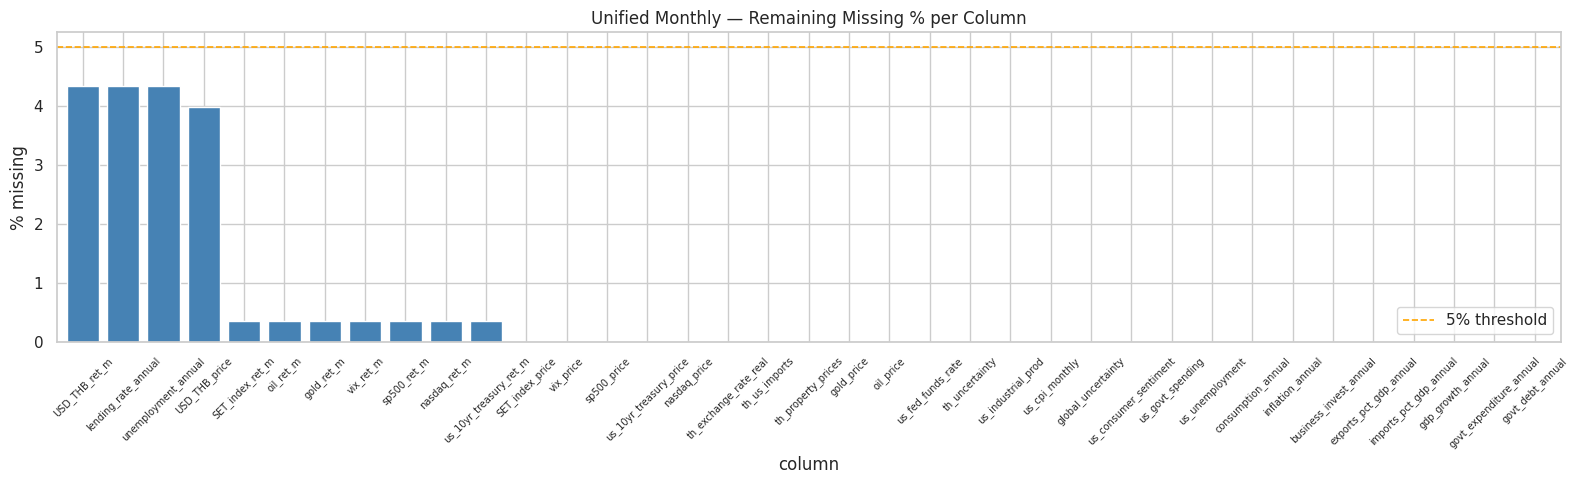


[OK] Ready for 03_correlation_analysis.ipynb


In [8]:
print('='*55)
print('CLEANING VALIDATION REPORT')
print('='*55)

print('\n[1] Time window')
print(f'  market  : {market.index[0].date()} → {market.index[-1].date()}')
print(f'  fred    : {fred.index[0].date()} → {fred.index[-1].date()}')
print(f'  macro   : {int(macro.index.min())} → {int(macro.index.max())}')

print('\n[2] Remaining missing after cleaning')
for name, df in [('market_daily', market), ('fred_monthly', fred_m),
                  ('macro_annual', macro),  ('unified', unified)]:
    miss = df.isna().sum().sum()
    pct  = miss / df.size * 100
    print(f'  {name:15s}: {miss:5d} missing cells ({pct:.1f}%)')

print('\n[3] Unified dataset')
print(f'  Shape       : {unified.shape}')
print(f'  Columns     : {unified.shape[1]}')
print(f'  Complete rows: {unified.dropna().shape[0]} / {len(unified)}')

# Visualize missingness in unified dataset
fig, ax = plt.subplots(figsize=(16, 5))
miss_pct = (unified.isna().mean() * 100).sort_values(ascending=False)
miss_pct.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.axhline(5, color='orange', ls='--', lw=1.2, label='5% threshold')
ax.set_title('Unified Monthly — Remaining Missing % per Column')
ax.set_xlabel('column'); ax.set_ylabel('% missing')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(); plt.tight_layout(); plt.show()

print('\n[OK] Ready for 03_correlation_analysis.ipynb')